# Exponential Smoothing with NumPyro: State Space Form

In the blog post ["Notes on Exponential Smoothing with NumPyro"](https://juanitorduz.github.io/exponential_smoothing_numpyro/) we implemented the damped Holt-Winters model in the **component form** of [Hyndman & Athanasopoulos, *FPP3*, §8.3](https://otexts.com/fpp3/holt-winters.html). A very nice observation was raised by [@theorashid](https://github.com/theorashid) in [issue #193](https://github.com/juanitorduz/website_projects/issues/193): when we forecast with the component-form model the credible intervals barely widen across the horizon. The reason is subtle but important. Quoting the issue:

> The models are written in component form, as in Hyndman 8.3. However, when we fitted this model, we found the error bars didn't increase as much as expected. My explanation for this is that the variance from `pred` is the same around each data point. And this variance isn't pushed forward to form a cone in the same way an autoregressive model does. The increasing error we see I think is entirely from the variability in the coefficients.
>
> We rewrote the model from component form into state space form, which is introduced in 8.5. It looks like the component form is just a "smoothing formula", whereas this state space form is a proper stochastic process that gets more uncertain over the forecast horizon. Anyway, when I fitted it, the uncertainty intervals grew and looked better than before.

This notebook addresses that point: we re-implement the damped Holt-Winters model using the **innovations state-space** (a.k.a. single-source-of-error, SSOE) representation of [FPP3 §8.5](https://otexts.com/fpp3/ets.html), specifically the `ETS(A, A_d, A)` model — additive error, additive damped trend, additive seasonality. The same random innovation $\varepsilon_t$ drives both the observation equation and the state transitions, so during forecasting (when `pred` is sampled rather than observed) the sampled innovation feeds back into the level, trend and seasonal states and the forecast uncertainty grows naturally over the horizon.

### What changes versus the component-form post

Concretely, compared to the [original implementation](https://juanitorduz.github.io/exponential_smoothing_numpyro/) the SSOE reformulation boils down to a handful of localised changes — all inside the model function, everything outside it (synthetic data, train-test split, inference helpers, ArviZ integration, plot style) stays the same:

1. **Unified transition function.** In the original post the state updates inside `transition_fn` were written in the component form and driven by the *observed* $y_t$ (via terms like $\alpha \, (y_t - s_{t-m})$). Here they are rewritten around a single **innovation** `error = pred - mu` — the level, trend and seasonal equations are all updated by the *same* `error`. That is the operational meaning of the "single source of error" in the remark above.
2. **No `jnp.where(t < t_max, ...)` branching.** The component-form model needed to "freeze" the state updates during forecasting (because feeding the sampled `pred` back through the component-form updates would double-count the emission noise). In the SSOE form training and forecasting use the *exact same* recursion — the only difference is whether `pred` is conditioned to data or sampled from $\mathcal{N}(\mu_t, \sigma)$ — so the branch disappears.
3. **No explicit $\phi_h = \phi + \phi^2 + \cdots + \phi^h$ sum.** The original post computed this multi-step damping factor inside a `fori_loop` at forecast time. Here the geometric decay emerges naturally from iterating $b_t = \phi \, b_{t-1} + \beta \, \varepsilon_t$ inside `scan`, so the explicit loop is gone.
4. **Reverse-mode autodiff.** Because there is no `fori_loop` we no longer need `forward_mode_differentiation=True` in `NUTS` — the default (reverse-mode) path, which is the faster and canonical one in NumPyro, now works.
5. **Slightly retuned priors.** We keep the priors *in shape* but tighten a few of them (Beta(5, 5) on the smoothing parameters, data-anchored $l_0$, a realistic-scale $b_0$, a tighter noise scale). This is a sampling-geometry fix, not a modelling change — see the model-definition section below for the full rationale.

Changes (1) and (2) together are what makes the forecast uncertainty grow naturally over the horizon. Once every state equation is driven by the same sampled innovation $\varepsilon_t$, iterating the recursion during forecasting propagates that innovation into $l_t$, $b_t$, $s_t$, and the posterior predictive fans out into a proper cone. This is precisely the behaviour the component-form implementation was missing.

**Thanks** to [@theorashid](https://github.com/theorashid) for the great feedback! 🙌

## Prepare Notebook

In [ ]:
from collections.abc import Callable

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import Array, random
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS, Predictive
from pydantic import BaseModel, Field

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

## Generate Synthetic Data

We use the same synthetic series as in the original post so that the two sets of forecasts can be compared directly: a cosine seasonal component plus a logarithmic trend, with additive Gaussian noise.

[Text(0.5, 0, 'time'), Text(0, 0.5, 'y'), Text(0.5, 1.0, 'Time Series Data')]

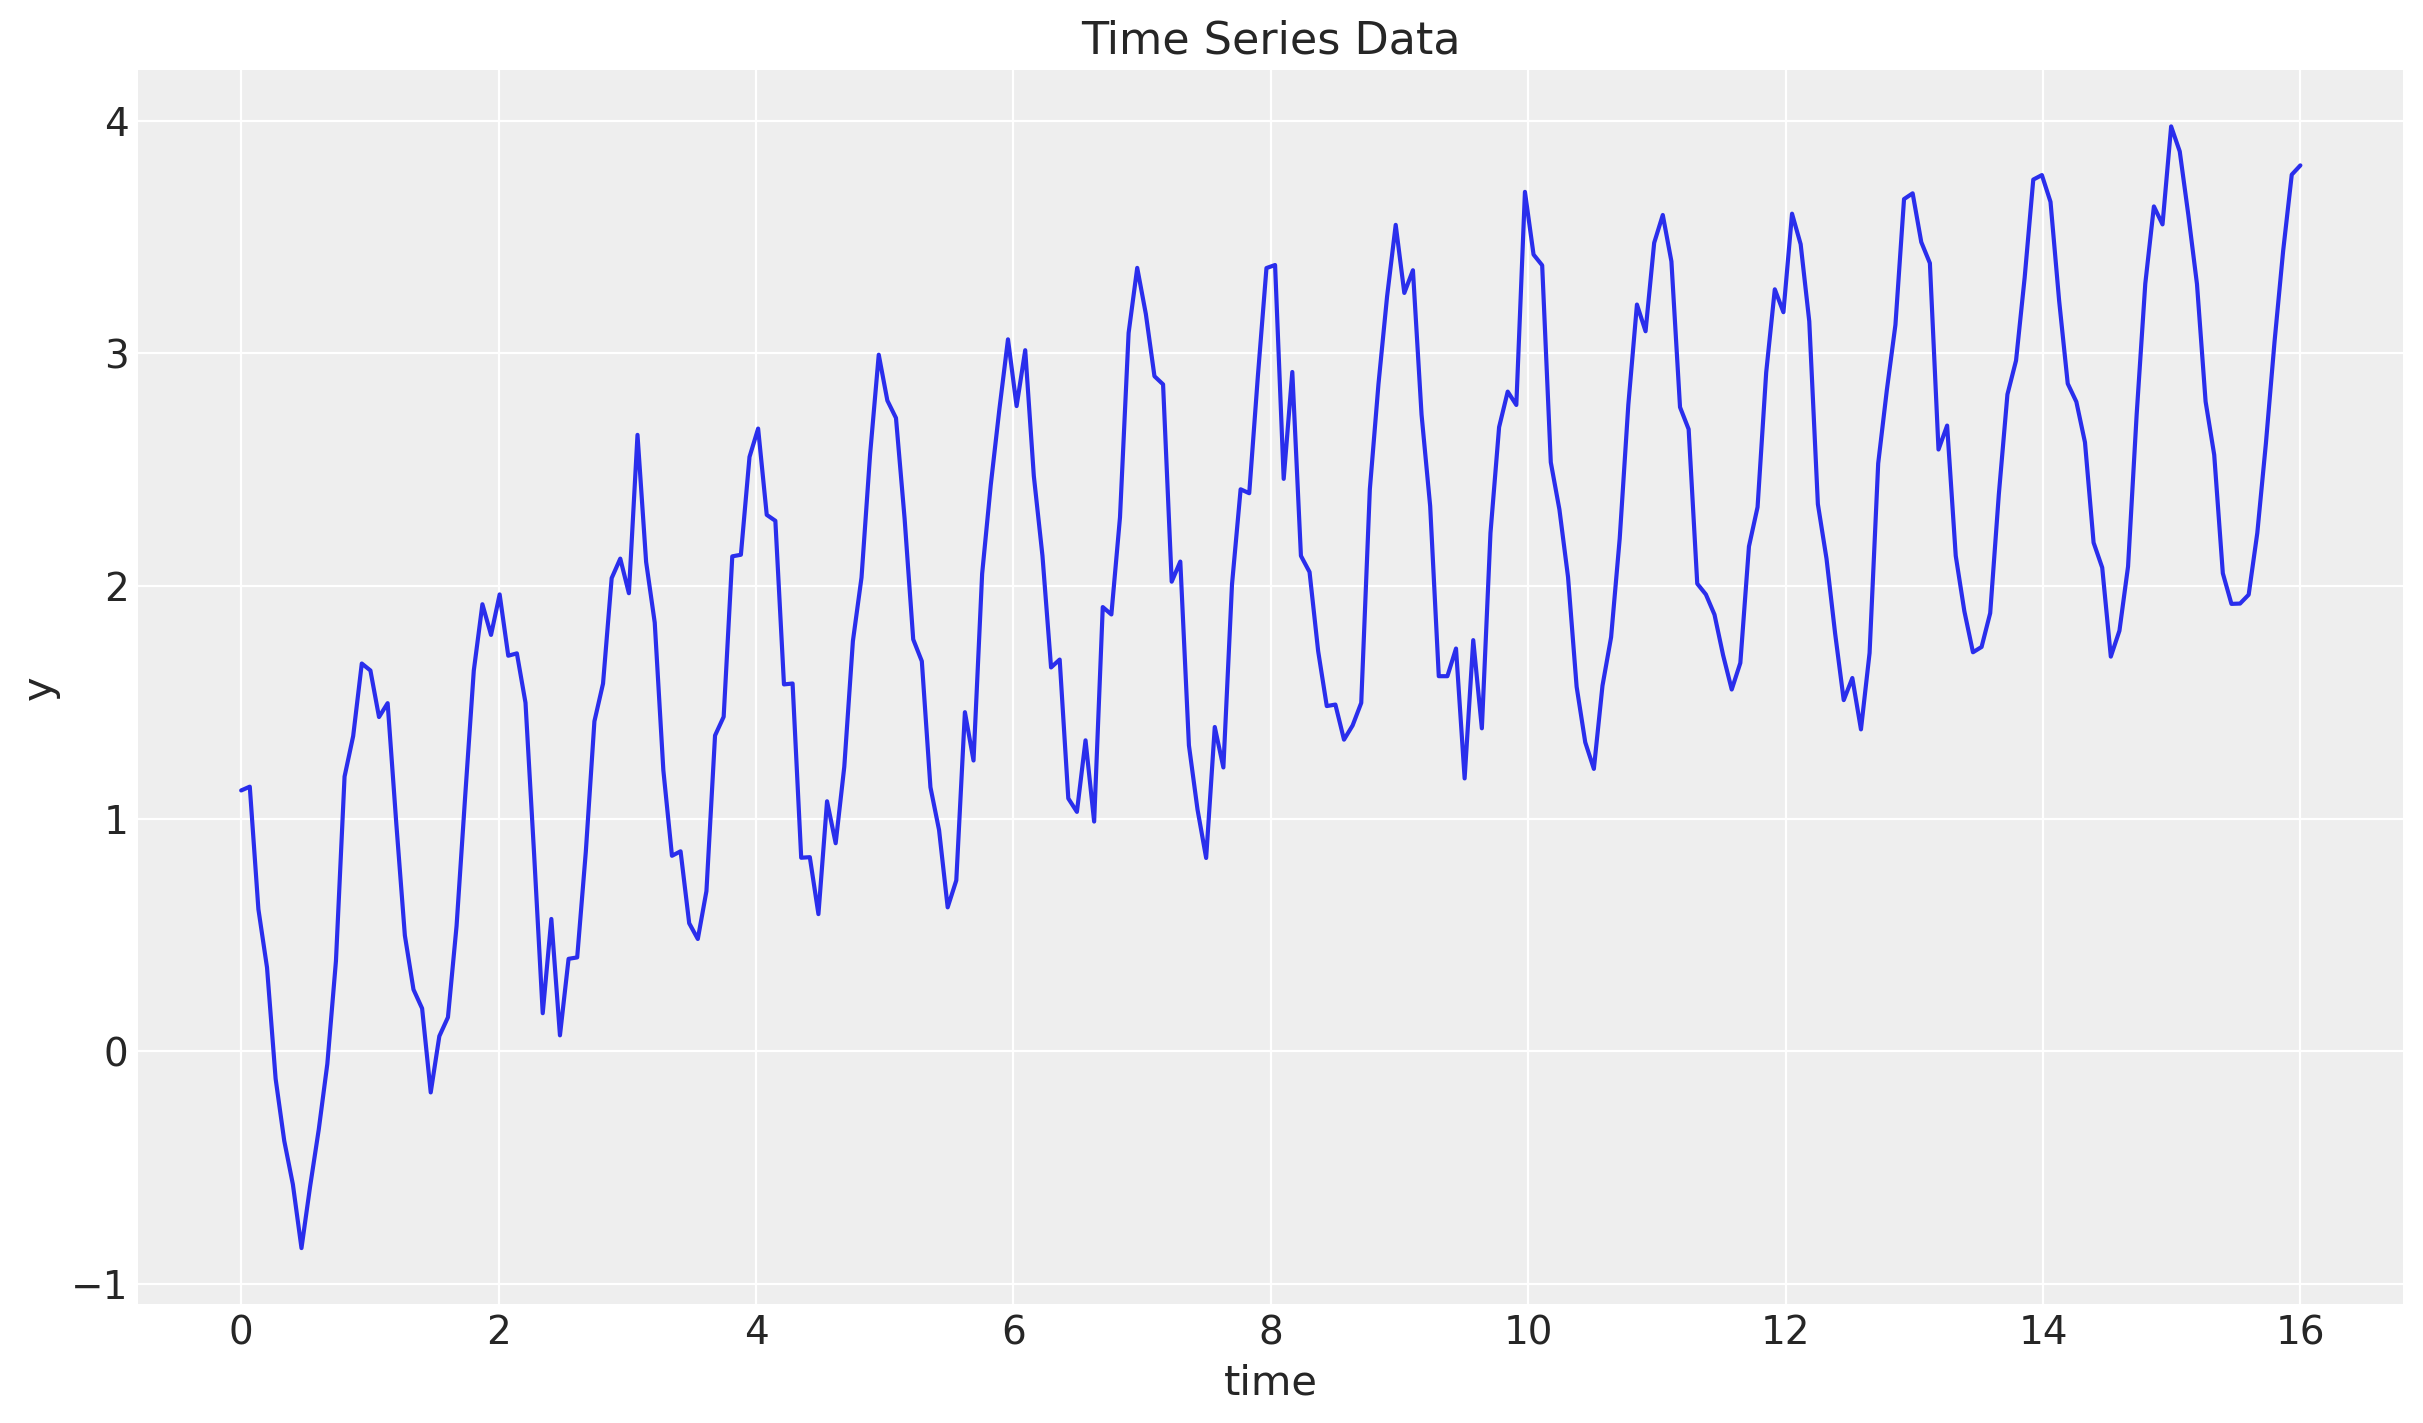

In [ ]:
n_seasons = 15
t = jnp.linspace(start=0, stop=n_seasons + 1, num=(n_seasons + 1) * n_seasons)
rng_key, rng_subkey = random.split(key=rng_key)
y = jnp.cos(2 * jnp.pi * t) + jnp.log(t + 1) + 0.2 * random.normal(rng_subkey, t.shape)

fig, ax = plt.subplots()
ax.plot(t, y)
ax.set(xlabel="time", ylabel="y", title="Time Series Data")

## Train - Test Split

[Text(0.5, 0, 'time'),
 Text(0, 0.5, 'y'),
 Text(0.5, 1.0, 'Time Series Data Split')]

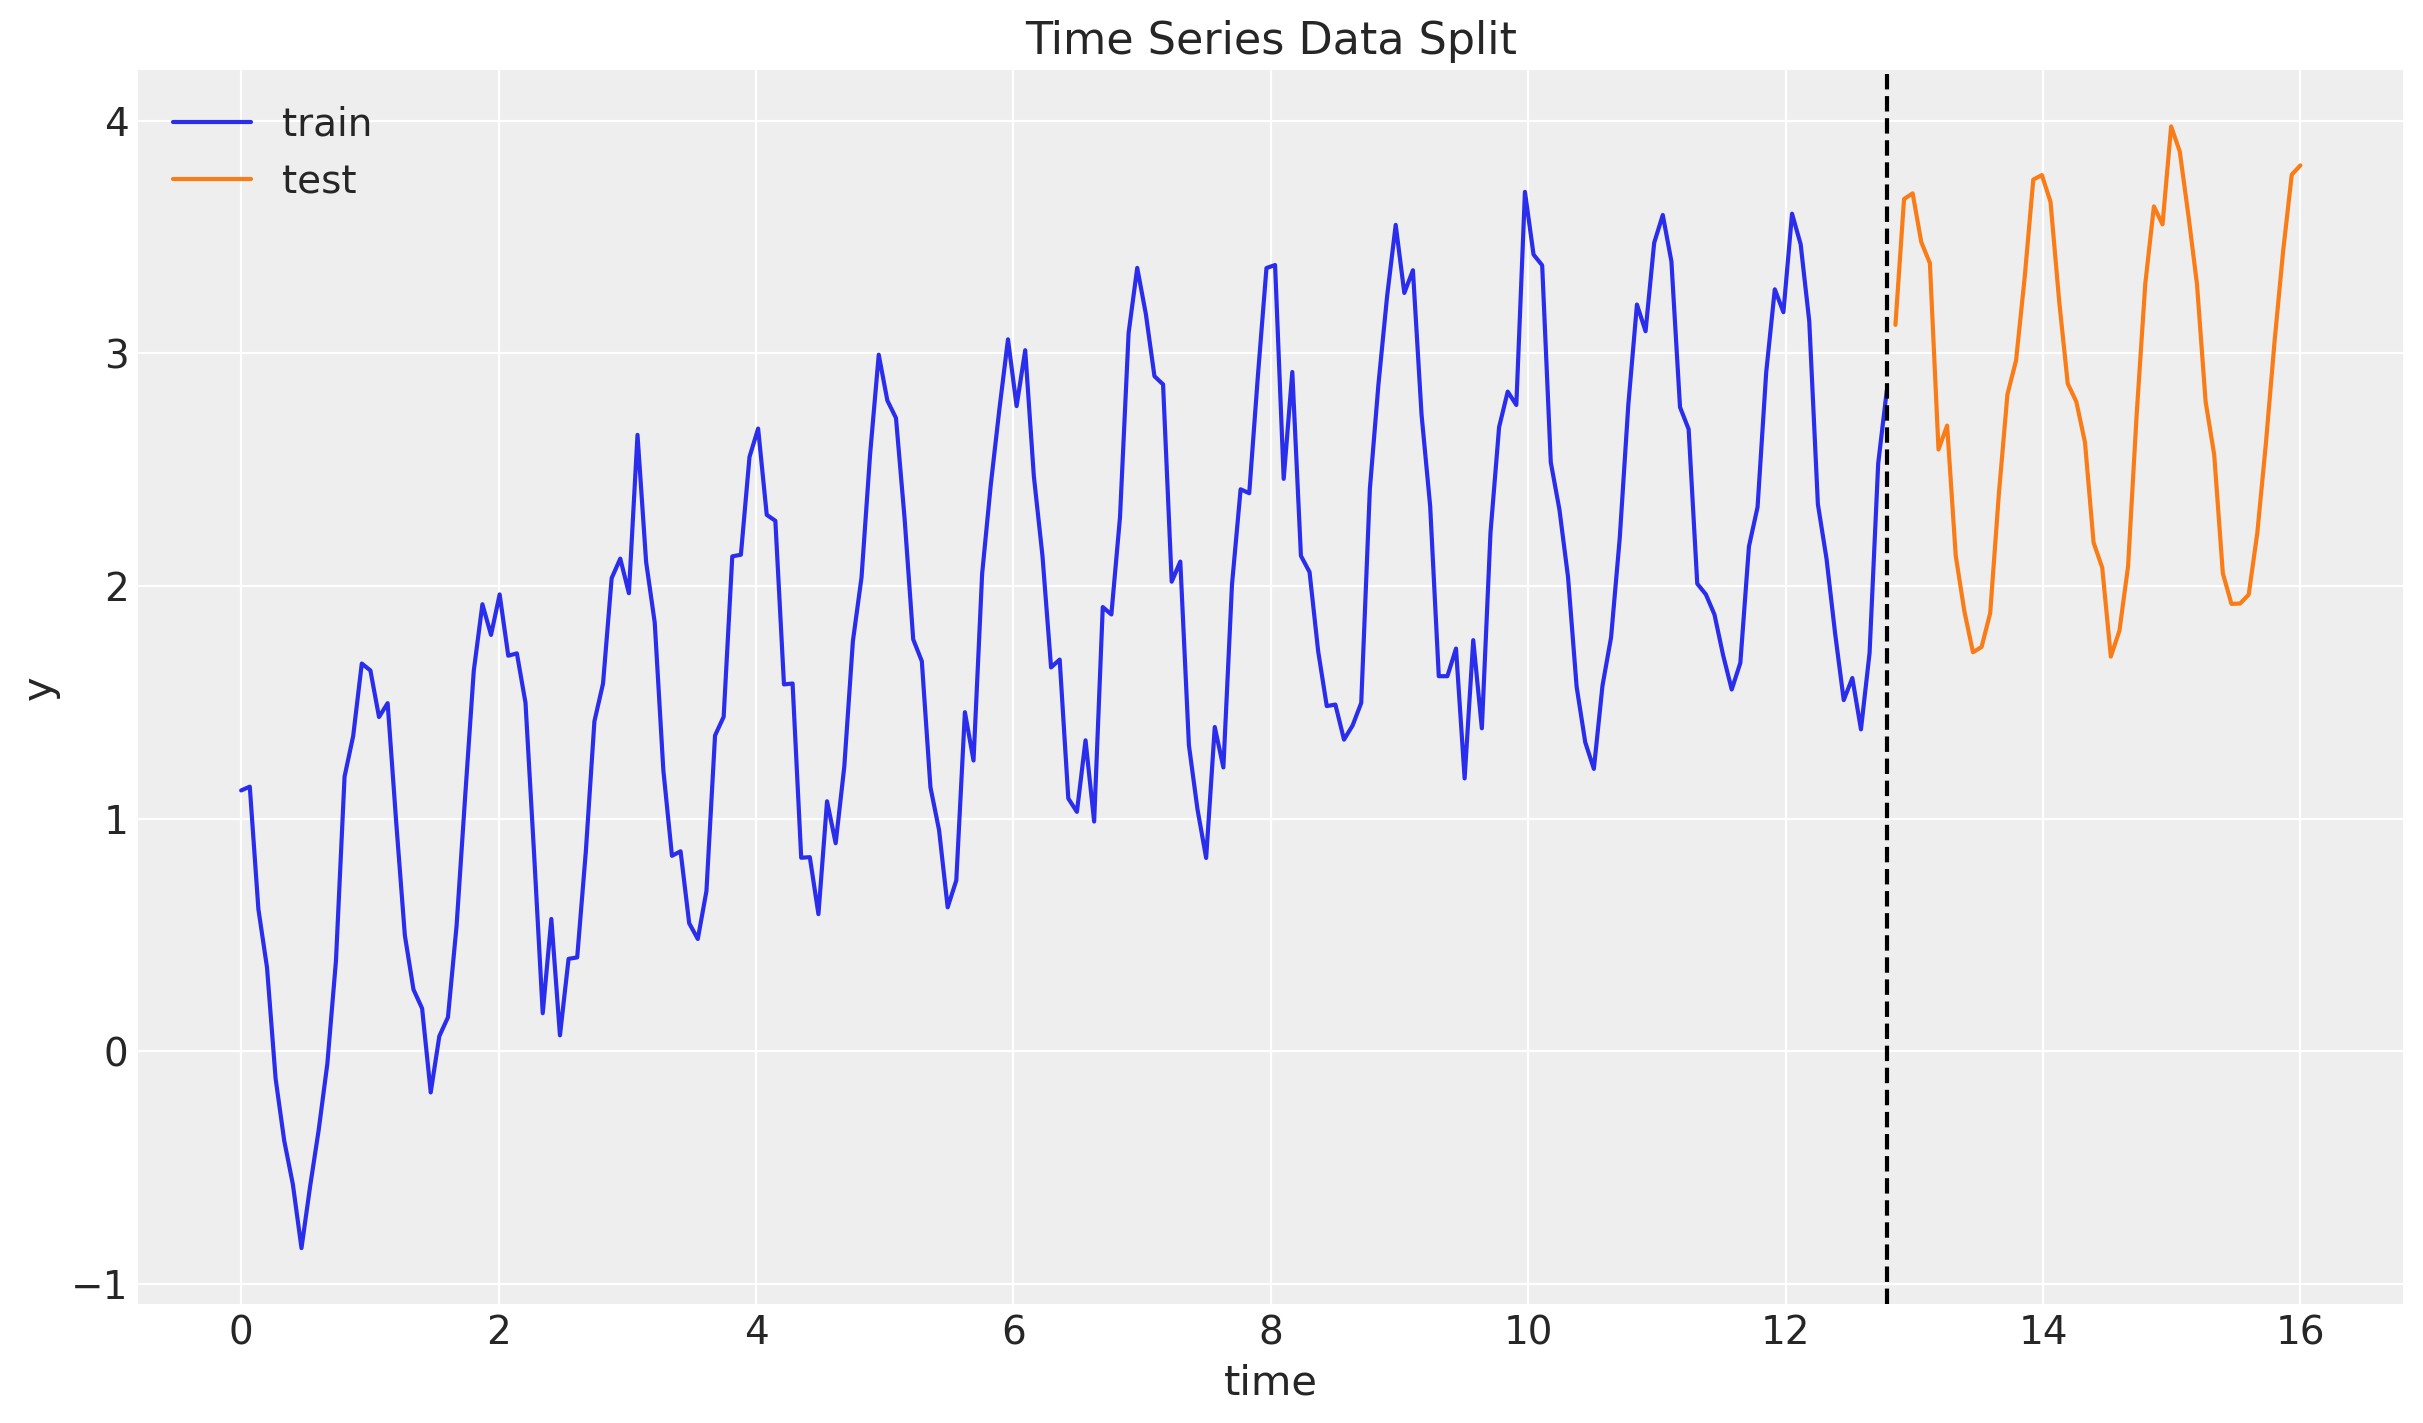

In [ ]:
n = y.size

prop_train = 0.8
n_train = round(prop_train * n)

y_train = y[:n_train]
t_train = t[:n_train]

y_test = y[n_train:]
t_test = t[n_train:]

fig, ax = plt.subplots()
ax.plot(t_train, y_train, color="C0", label="train")
ax.plot(t_test, y_test, color="C1", label="test")
ax.axvline(x=t_train[-1], c="black", linestyle="--")
ax.legend()
ax.set(xlabel="time", ylabel="y", title="Time Series Data Split")

## From Component Form to State Space Form

For quick reference, the damped Holt-Winters model in **component form** (as in the original post) is

\begin{align*}
\hat{y}_{t+h|t} = & \: l_t + \phi_h b_t + s_{t + h - m(k + 1)} \\
l_t = & \: \alpha(y_t - s_{t - m}) + (1 - \alpha)(l_{t-1} + \phi b_{t-1}) \\
b_t = & \:  \beta^*(l_t - l_{t-1}) + (1 - \beta^*)\phi b_{t-1} \\
s_t = & \:  \gamma(y_t - l_{t-1} - \phi b_{t-1}) + (1 - \gamma)s_{t-m}
\end{align*}

with $\phi_h = \phi + \phi^2 + \cdots + \phi^h$. The state updates are driven by the *observed* $y_t$, which is fine for training but means the forecast distribution collapses to the (deterministic) recursion `mu` plus a single emission noise term — the emission noise is never fed back into $l_t$, $b_t$ or $s_t$, so the forecast bands stay narrow.

The **innovations state space** (or SSOE) form of the same model, `ETS(A, A_d, A)`, is the *Gaussian linear state space* system

\begin{align*}
y_t &= l_{t-1} + \phi b_{t-1} + s_{t-m} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2) \\
l_t &= l_{t-1} + \phi b_{t-1} + \alpha \, \varepsilon_t \\
b_t &= \phi b_{t-1} + \beta \, \varepsilon_t \\
s_t &= s_{t-m} + \gamma \, \varepsilon_t
\end{align*}

The *same* $\varepsilon_t$ appears in every equation — that is the "single source of error". Two consequences matter for us:

1. During training we condition `pred = y[t]`, so the innovation $\varepsilon_t = y_t - \mu_t$ is exactly the one-step-ahead forecast error, and the state updates reduce to the familiar Kalman-style corrections.
2. During forecasting `pred` is *sampled* from $\mathcal{N}(\mu_t, \sigma)$; the sampled $\varepsilon_t$ then propagates into $l_t$, $b_t$, $s_t$ and drives the next step's $\mu$. The forecast distribution therefore fans out into a proper cone — precisely what we want.

A small reparameterisation note: we keep the *component-form* smoothing parameters $\beta^\ast$ and $\gamma^\ast$ as priors (each on $[0, 1]$), and map them to the state-space coefficients via
$$
\beta = \beta^\ast \, \alpha, \qquad \gamma = \gamma^\ast \, (1 - \alpha),
$$
so the priors are directly comparable with those in the original post. See [FPP3 §8.5](https://otexts.com/fpp3/ets.html#etsaan-holts-linear-method-with-additive-errors) for the derivation.

Finally, note that in the SSOE form we do **not** need the explicit $\phi_h = \phi + \phi^2 + \cdots + \phi^h$ sum — and therefore no `fori_loop` and no `forward_mode_differentiation=True`. The geometric damping of the trend emerges naturally from iterating the transition $b_t = \phi b_{t-1} + \beta \, \varepsilon_t$ inside `scan`.

## Damped Holt-Winters State Space Model

The structural change versus the component-form implementation is entirely inside `transition_fn`. We do tighten a few of the priors, though — not because the original priors are "wrong", but because the SSOE posterior has a very different *geometry* and the Beta$(2, 2)$ / $\mathcal{N}(0, 1)$ / $\text{HalfNormal}(1)$ priors of the original post land NUTS in high-curvature regions that produce divergences. The refinements below are aimed at sampling geometry only:

- **Smoothing parameters $\alpha$, $\beta^\ast$, $\gamma^\ast$: $\text{Beta}(2, 2) \to \text{Beta}(5, 5)$.** The mode stays at $0.5$ but the density at the boundaries drops from $0$-linear to essentially flat-zero. This matters because the SSOE reparameterisation $\beta = \alpha \, \beta^\ast$, $\gamma = (1 - \alpha) \, \gamma^\ast$ creates *funnels* at $\alpha = 0$ and $\alpha = 1$: as $\alpha \to 0$ the trend coefficient $\beta$ collapses and $\beta^\ast$ becomes locally unidentifiable (flat likelihood, non-zero prior gradient); symmetrically at $\alpha \to 1$ for $\gamma^\ast$. With $\text{Beta}(2, 2)$ priors the sampler happily walks into those corners and diverges; $\text{Beta}(5, 5)$ simply keeps it away.
- **Initial level $l_0$: $\mathcal{N}(0, 1) \to \mathcal{N}(y_0, 1)$.** Anchoring on the first observation means the warmup does not have to walk $l_0$ across the data scale before the smoothing parameters can be identified. The variance is unchanged — the prior is still weakly informative.
- **Initial trend $b_0$: $\mathcal{N}(0.5, 1) \to \mathcal{N}(0, 0.1)$.** The original prior was oddly centred at $0.5$ and was much wider than any realistic one-step trend. With $\phi$ small, $b_0$ is only identified through the first few observations and the wide prior creates a long weakly-identified direction in the posterior.
- **Noise $\sigma$: $\text{HalfNormal}(1) \to \text{HalfNormal}(0.5)$.** Still comfortably above the true noise scale of the synthetic data ($\approx 0.2$), but tighter — this breaks the $\sigma$–$\alpha$ correlation (large $\alpha$ + small $\sigma$ and small $\alpha$ + large $\sigma$ give similar likelihoods) that the original wide prior left loose.
- **Damping $\phi \sim \text{Beta}(2, 5)$** and the seasonal initials $\mathcal{N}(0, 1)$ are left unchanged — the trace of the original SSOE fit shows both are already well identified.

In [ ]:
def damped_holt_winters_ssm_model(y: Array, n_seasons: int, future: int = 0) -> None:
    # Get time series length
    t_max = y.shape[0]

    # --- Priors ---

    ## Level
    level_smoothing = numpyro.sample("level_smoothing", dist.Beta(5, 5))
    level_init = numpyro.sample("level_init", dist.Normal(y[0], 1))

    ## Trend (component-form beta*; in SSOE form beta = beta* * alpha)
    trend_smoothing = numpyro.sample("trend_smoothing", dist.Beta(5, 5))
    trend_init = numpyro.sample("trend_init", dist.Normal(0, 0.1))

    ## Seasonality (component-form gamma*; in SSOE form gamma = gamma* * (1 - alpha))
    seasonality_smoothing = numpyro.sample("seasonality_smoothing", dist.Beta(5, 5))
    adj_seasonality_smoothing = seasonality_smoothing * (1 - level_smoothing)

    ## Damping
    phi = numpyro.sample("phi", dist.Beta(2, 5))

    with numpyro.plate("n_seasons", n_seasons):
        seasonality_init = numpyro.sample("seasonality_init", dist.Normal(0, 1))

    ## Noise
    noise = numpyro.sample("noise", dist.HalfNormal(0.5))

    # --- Transition Function ---

    def transition_fn(carry, t):
        previous_level, previous_trend, previous_seasonality = carry

        # Observation equation: y_t = l_{t-1} + φ b_{t-1} + s_{t-m} + ε_t
        mu = previous_level + phi * previous_trend + previous_seasonality[0]

        pred = numpyro.sample("pred", dist.Normal(loc=mu, scale=noise))

        # SSOE innovation. During training pred is conditioned to y[t] so
        # error = y[t] - mu is the one-step-ahead forecast error. During
        # forecasting pred is sampled from N(mu, noise) so error ~ N(0, noise)
        # and propagates through the state updates below.
        error = pred - mu

        # State updates (innovations form)
        level = previous_level + phi * previous_trend + level_smoothing * error
        trend = phi * previous_trend + trend_smoothing * level_smoothing * error
        new_season = previous_seasonality[0] + adj_seasonality_smoothing * error

        # Rotate the seasonal buffer so that index 0 always holds s_{t-m}.
        seasonality = jnp.concatenate(
            [previous_seasonality[1:], new_season[None]], axis=0
        )

        return (level, trend, seasonality), pred

    # --- Run Scan ---

    with numpyro.handlers.condition(data={"pred": y}):
        _, preds = scan(
            transition_fn,
            (level_init, trend_init, seasonality_init),
            jnp.arange(t_max + future),
        )

    # --- Forecast ---
    if future > 0:
        numpyro.deterministic("y_forecast", preds[-future:])

A few things to notice versus the component-form implementation in the original post:

- There is no `jnp.where(t < t_max, ...)` branching inside the state updates. The SSOE formulation treats training and forecasting uniformly: the only difference between the two regimes is whether `pred` is conditioned or sampled — the recursion itself is unchanged.
- There is no `fori_loop` and no `phi_step = phi + phi^2 + ... + phi^h` computation. The damping $\phi^h$ geometric decay emerges from iterating $b_t = \phi b_{t-1} + \beta \, \varepsilon_t$ inside `scan`.
- Because we removed `fori_loop` we can use the default reverse-mode differentiation for NUTS — no need for `forward_mode_differentiation=True`.

## Inference

We reuse the same helper functions as the original post.

In [ ]:
class InferenceParams(BaseModel):
    num_warmup: int = Field(2_000, ge=1)
    num_samples: int = Field(2_000, ge=1)
    num_chains: int = Field(4, ge=1)


def run_inference(
    rng_key: Array,
    model: Callable,
    args: InferenceParams,
    *model_args,
    **nuts_kwargs,
) -> MCMC:
    sampler = NUTS(model, **nuts_kwargs)
    mcmc = MCMC(
        sampler=sampler,
        num_warmup=args.num_warmup,
        num_samples=args.num_samples,
        num_chains=args.num_chains,
    )
    mcmc.run(rng_key, *model_args)
    return mcmc

In [ ]:
inference_params = InferenceParams()
rng_key, rng_subkey = random.split(key=rng_key)
damped_holt_winters_ssm_mcmc = run_inference(
    rng_subkey,
    damped_holt_winters_ssm_model,
    inference_params,
    y_train,
    n_seasons,
    target_accept_prob=0.95,
)

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [ ]:
damped_holt_winters_ssm_idata = az.from_numpyro(posterior=damped_holt_winters_ssm_mcmc)

az.summary(data=damped_holt_winters_ssm_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
level_init,0.286,0.293,-0.241,0.852,0.009,0.005,1045.0,1997.0,1.0
level_smoothing,0.228,0.045,0.145,0.309,0.001,0.001,3891.0,4153.0,1.0
noise,0.234,0.013,0.210,0.258,0.000,0.000,3908.0,4906.0,1.0
phi,0.264,0.154,0.016,0.544,0.003,0.002,3468.0,4084.0,1.0
seasonality_init[0],0.857,0.285,0.311,1.376,0.009,0.005,975.0,1800.0,1.0
seasonality_init[1],0.768,0.286,0.228,1.295,0.009,0.005,958.0,1582.0,1.0
seasonality_init[2],0.488,0.283,-0.028,1.028,0.009,0.005,976.0,1830.0,1.0
seasonality_init[3],0.091,0.283,-0.412,0.647,0.009,0.005,950.0,1681.0,1.0
seasonality_init[4],-0.325,0.283,-0.838,0.216,0.009,0.005,956.0,1601.0,1.0
seasonality_init[5],-0.718,0.283,-1.276,-0.204,0.009,0.005,995.0,1869.0,1.0


In [ ]:
print(
    f"""Divergences: {
        damped_holt_winters_ssm_idata["sample_stats"]["diverging"].sum().item()
    }"""
)

Divergences: 0


Text(0.5, 0.98, 'Damped Holt-Winters (State Space) Trace')

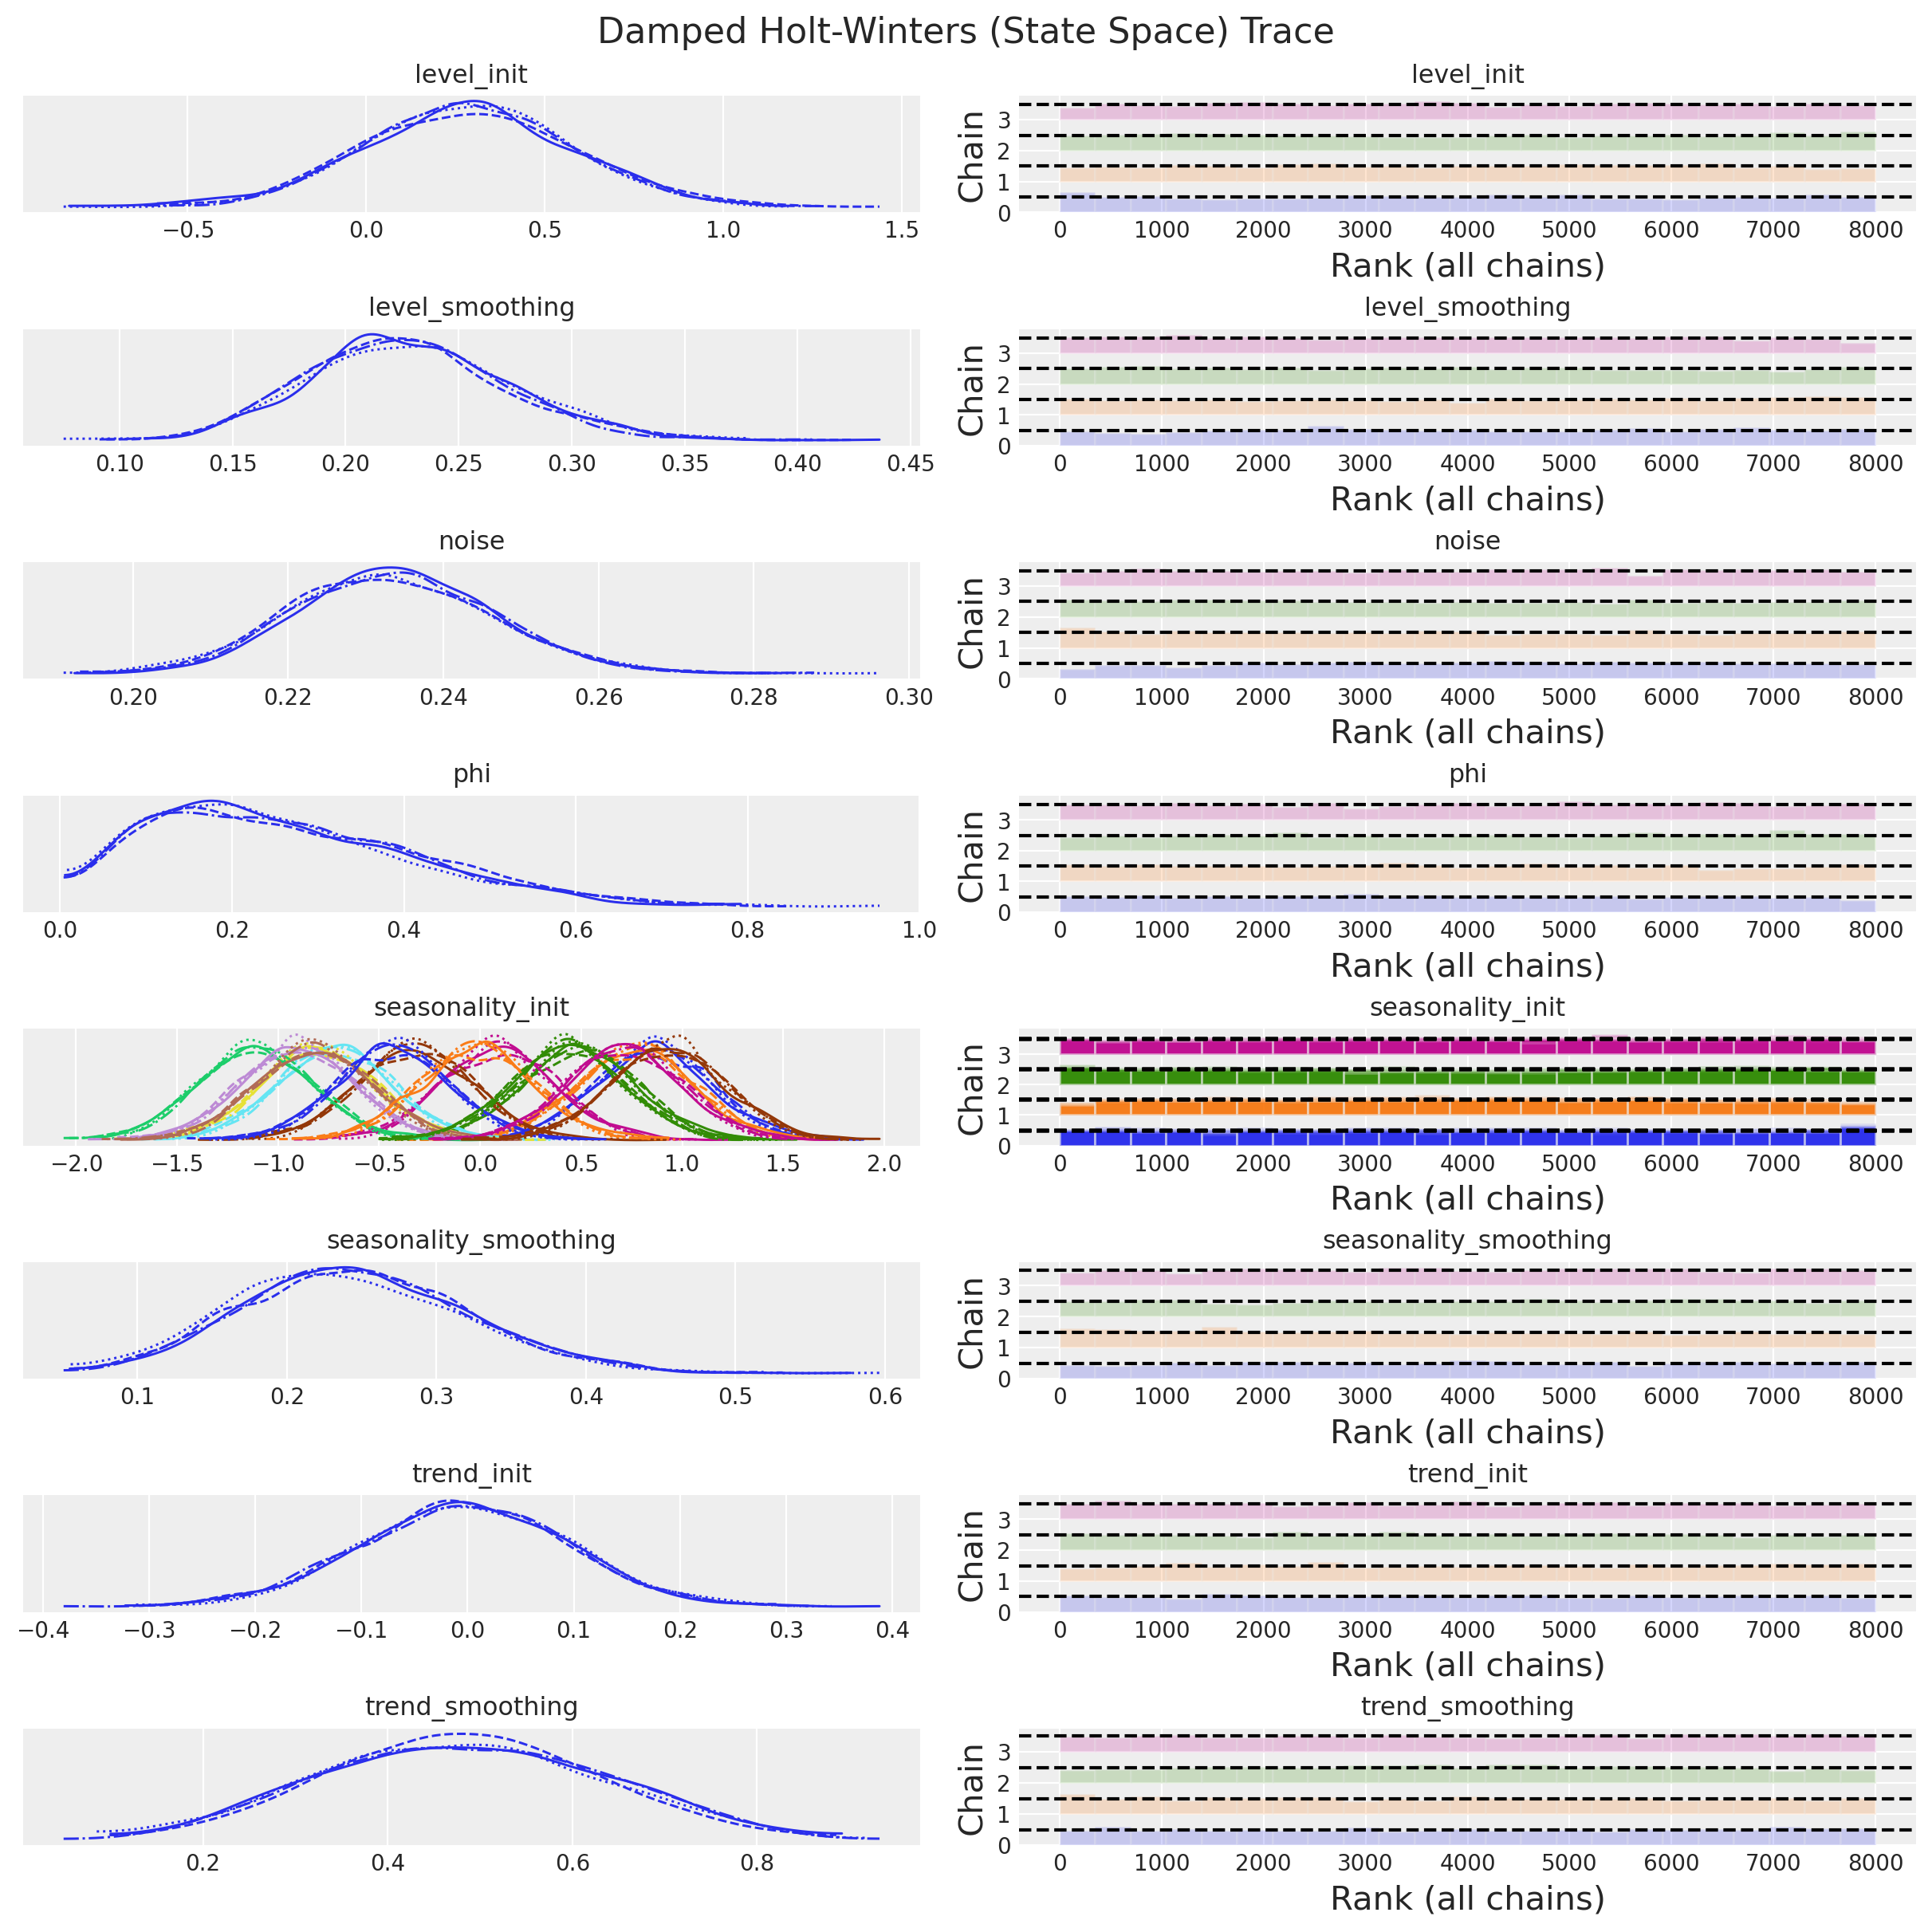

In [ ]:
axes = az.plot_trace(
    data=damped_holt_winters_ssm_idata,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 12), "layout": "constrained"},
)
plt.gcf().suptitle("Damped Holt-Winters (State Space) Trace", fontsize=16)

## Forecast

In [ ]:
def forecast(
    rng_key: Array, model: Callable, samples: dict[str, Array], *model_args
) -> dict[str, Array]:
    predictive = Predictive(
        model=model,
        posterior_samples=samples,
        return_sites=["y_forecast"],
    )
    return predictive(rng_key, *model_args)

In [ ]:
rng_key, rng_subkey = random.split(key=rng_key)
damped_holt_winters_ssm_forecast = forecast(
    rng_subkey,
    damped_holt_winters_ssm_model,
    damped_holt_winters_ssm_mcmc.get_samples(),
    y_train,
    n_seasons,
    y_test.size,
)

damped_holt_winters_ssm_posterior_predictive = az.from_numpyro(
    posterior_predictive=damped_holt_winters_ssm_forecast,
    coords={"t": t_test},
    dims={"y_forecast": ["t"]},
)

[Text(0.5, 0, 'time'),
 Text(0, 0.5, 'y'),
 Text(0.5, 1.0, 'Damped Holt Winters Model Forecast (State Space Form)')]

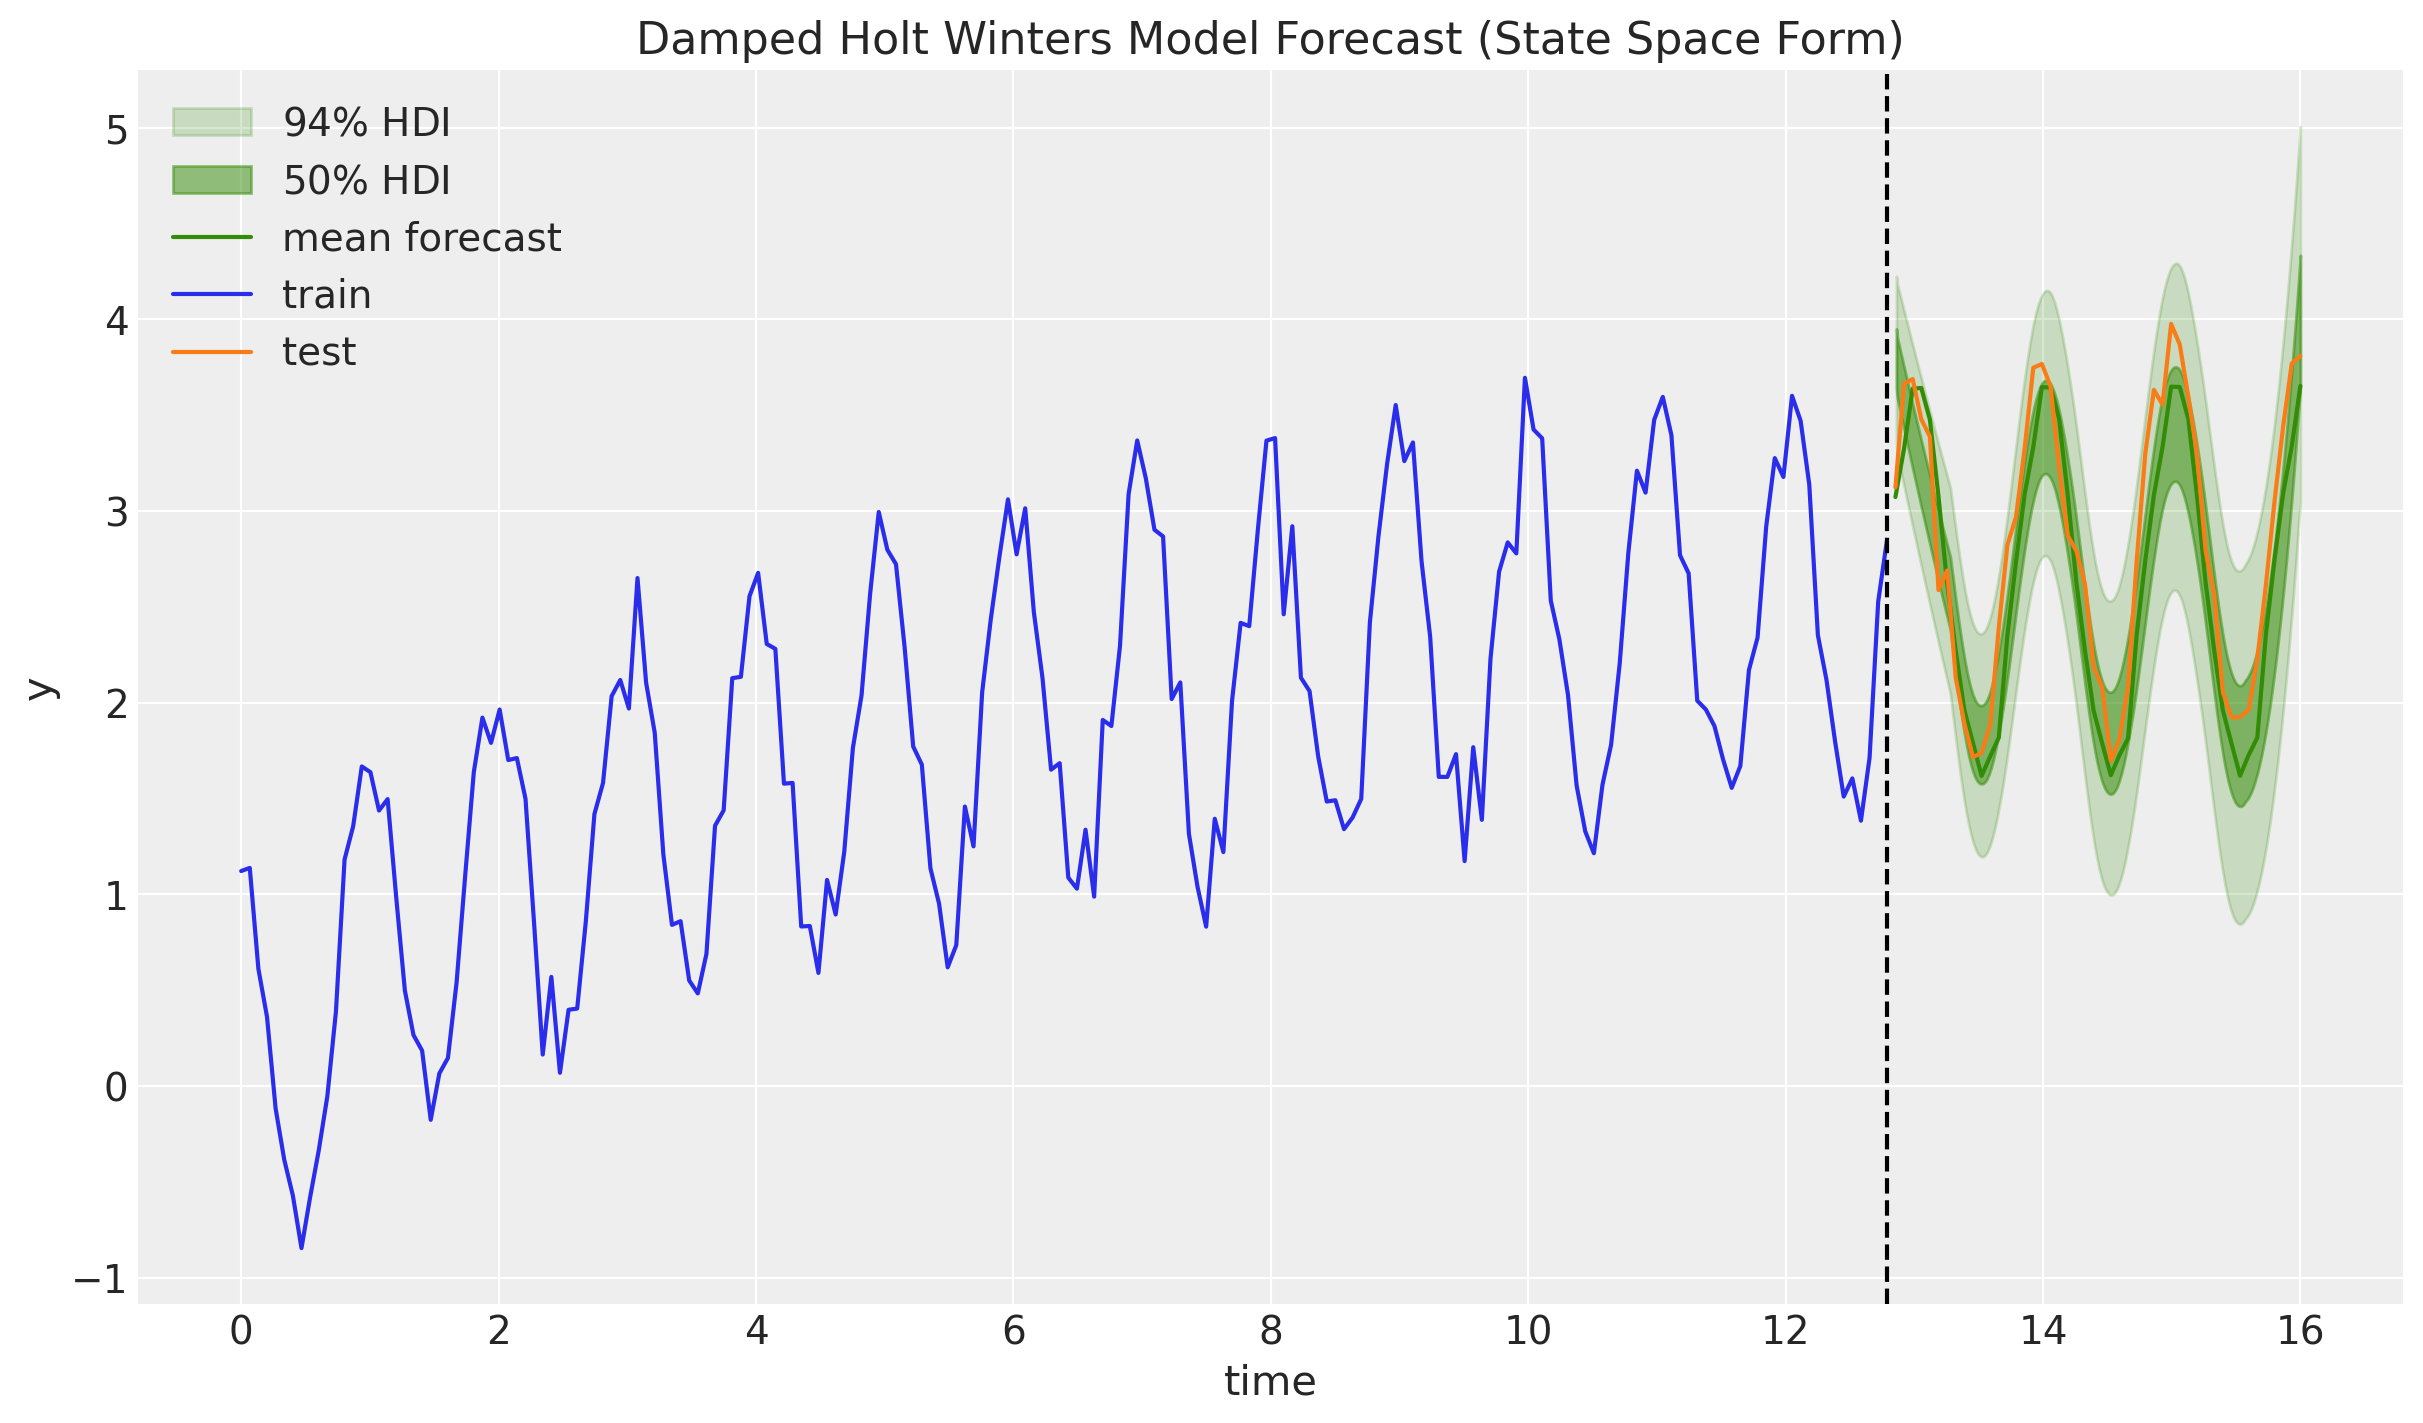

In [ ]:
fig, ax = plt.subplots()
az.plot_hdi(
    x=t_test,
    y=damped_holt_winters_ssm_posterior_predictive["posterior_predictive"][
        "y_forecast"
    ],
    hdi_prob=0.94,
    color="C2",
    fill_kwargs={"alpha": 0.2, "label": r"$94\%$ HDI"},
    ax=ax,
)
az.plot_hdi(
    x=t_test,
    y=damped_holt_winters_ssm_posterior_predictive["posterior_predictive"][
        "y_forecast"
    ],
    hdi_prob=0.50,
    color="C2",
    fill_kwargs={"alpha": 0.5, "label": r"$50\%$ HDI"},
    ax=ax,
)
ax.plot(
    t_test,
    damped_holt_winters_ssm_posterior_predictive["posterior_predictive"][
        "y_forecast"
    ].mean(dim=("chain", "draw")),
    color="C2",
    label="mean forecast",
)
ax.plot(t_train, y_train, color="C0", label="train")
ax.plot(t_test, y_test, color="C1", label="test")
ax.axvline(x=t_train[-1], c="black", linestyle="--")
ax.legend()
ax.set(
    xlabel="time",
    ylabel="y",
    title="Damped Holt Winters Model Forecast (State Space Form)",
)

Compared to the component-form plot in the original post, the $94\%$ and $50\%$ HDIs now visibly fan out across the forecast horizon — the sampled innovation $\varepsilon_t$ at each step feeds back into the level, trend and seasonal states, and the accumulated uncertainty produces a proper forecast cone. This is exactly the behaviour we should expect from a stochastic state space model, and it is what the component form was missing.

Two small caveats worth keeping in mind:

- The SSOE form assumes that the observation noise and the state-transition innovation are **the same** random variable. As noted in [FPP3 §8.5](https://otexts.com/fpp3/ets.html#other-ets-models), this is a fairly strong assumption, but it is the canonical one for the ETS family and gives the model a nice likelihood-based interpretation.
- We kept the component-form prior on the trend smoothing ($\beta^\ast$) and scaled it by $\alpha$ at use time, because $\beta^\ast$ has a clean interpretation on $[0, 1]$. This is not essential — a direct prior on the SSOE coefficient $\beta$ would also work.

Thanks again to [@theorashid](https://github.com/theorashid) for [issue #193](https://github.com/juanitorduz/website_projects/issues/193) — the improvement is visible at a glance.